# 1. IMPORT LIBRARIES


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# LOAD DATASET

In [3]:
df=pd.read_csv("StudentsPerformance.csv")

# BASIC EXPLORATION

In [4]:
print(df.head())
print(df.info())
print(df.describe())


   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

# FEATURE ENGINEERING


In [5]:
# Average score
df['average score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Performance category
def performance(score):
    if score >= 80:
        return "Excellent"
    elif score >= 60:
        return "Good"
    else:
        return "Poor"

df['performance'] = df['average score'].apply(performance)


 ## DATA VISUALIZATION

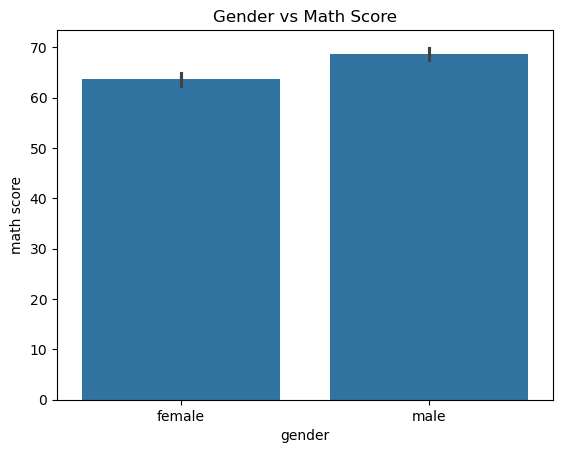

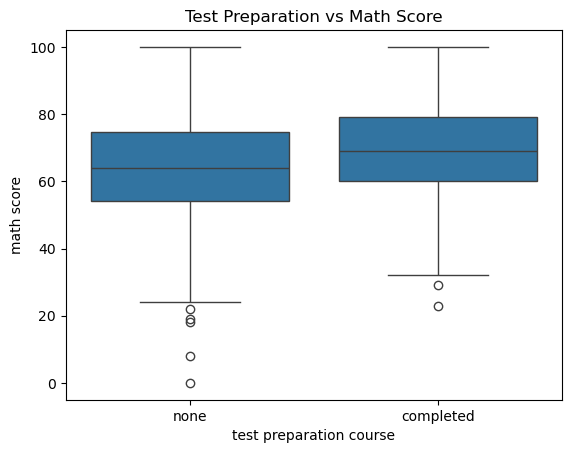

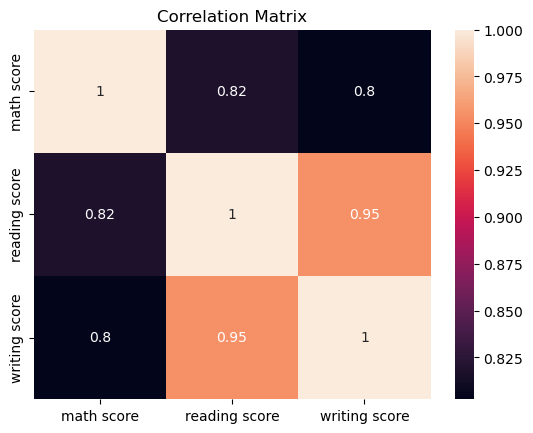

In [6]:
# Gender vs Math Score
sns.barplot(x='gender', y='math score', data=df)
plt.title("Gender vs Math Score")
plt.show()

# Test preparation effect
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title("Test Preparation vs Math Score")
plt.show()

# Correlation heatmap
sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [7]:
#  DATA PREPROCESSING

In [8]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['race/ethnicity'] = le.fit_transform(df['race/ethnicity'])
df['parental level of education'] = le.fit_transform(df['parental level of education'])
df['lunch'] = le.fit_transform(df['lunch'])
df['test preparation course'] = le.fit_transform(df['test preparation course'])
df['performance'] = le.fit_transform(df['performance'])

# FEATURES & TARGET

In [9]:
X = df.drop(['math score'], axis=1)
y = df['math score']


# TRAIN TEST SPLIT

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

 # MODEL TRAINING

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

# PREDICTIONS

In [12]:
y_pred = model.predict(X_test)


# EVALUATION


In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)



📊 Model Performance:
MAE: 2.7194413768882034e-14
MSE: 9.24941517984463e-28
RMSE: 3.0412851197881187e-14
R2 Score: 1.0


#  SAMPLE PREDICTION

In [15]:
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = model.predict(sample)

print("\n🎯 Sample Prediction (Math Score):", prediction[0])


🎯 Sample Prediction (Math Score): 91.00000000000007


C:\Users\ABC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
